# 3. Линейные слои, функции активации и визуализация обучения

**Цель:** Реализовать полносвязные слои, изучить функции активации, построить классификатор и визуализировать обучение.

---

In [1]:
import sys, os, logging, math
LOG_LEVEL = os.getenv("LOG_LEVEL", "DEBUG")
logging.basicConfig(level=getattr(logging, LOG_LEVEL), format="%(asctime)s [%(levelname)s] %(name)s: %(message)s", stream=sys.stderr)
log = logging.getLogger("linear")

# PyTorch и нейросетевые модули
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

# Определяем устройство (MPS для Apple Silicon, CPU — fallback)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
log.info("Используем устройство: %s", device)


2026-06-01 00:23:29,501 [DEBUG] matplotlib: matplotlib data path: /Users/demanbudaev/PycharmProjects/Ashat_AI/.venv/lib/python3.9/site-packages/matplotlib/mpl-data


2026-06-01 00:23:29,509 [DEBUG] matplotlib: CONFIGDIR=/Users/demanbudaev/.matplotlib


2026-06-01 00:23:29,514 [DEBUG] matplotlib: interactive is False


2026-06-01 00:23:29,514 [DEBUG] matplotlib: platform is darwin


2026-06-01 00:23:29,543 [DEBUG] matplotlib: CACHEDIR=/Users/demanbudaev/.matplotlib


2026-06-01 00:23:29,545 [DEBUG] matplotlib.font_manager: Using fontManager instance from /Users/demanbudaev/.matplotlib/fontlist-v390.json


2026-06-01 00:23:30,900 [INFO] linear: Используем устройство: mps


## 3.1 Линейный слой (nn.Linear) изнутри

In [2]:
log.debug("Inspecting nn.Linear internals")

# nn.Linear(in_features, out_features, bias=True) — полносвязный слой
# Это y = x @ W^T + b, где W — матрица весов, b — смещение
# in_features → out_features: например 4 входа → 3 выхода
linear = nn.Linear(in_features=4, out_features=3, bias=True)
print(f"Weight shape: {linear.weight.shape}")  # (out_features, in_features) = (3, 4)
print(f"Bias shape:   {linear.bias.shape}")    # (out_features,) = (3,)
print(f"Weight:\n{linear.weight.data}")
print(f"Bias: {linear.bias.data}")

# Прямой проход: (batch, 4) → (batch, 3)
x = torch.randn(2, 4)
y = linear(x)
print(f"Input: {x.shape} -> Output: {y.shape}")
print(f"Output:\n{y}")

# Ручная реализация Linear: x @ W^T + b
# W.shape = (3, 4), поэтому транспонируем: W^T = (4, 3)
# x @ W^T → (2,4) @ (4,3) → (2,3)
y_manual = x @ linear.weight.T + linear.bias
print(f"Manual output matches: {torch.allclose(y, y_manual)}")


2026-06-01 00:23:30,904 [DEBUG] linear: Inspecting nn.Linear internals


Weight shape: torch.Size([3, 4])
Bias shape:   torch.Size([3])
Weight:
tensor([[ 0.3609,  0.1407,  0.1557, -0.3779],
        [ 0.2963, -0.1428, -0.2419, -0.2867],
        [ 0.2406,  0.3106, -0.2399,  0.1390]])
Bias: tensor([0.1946, 0.2613, 0.2449])
Input: torch.Size([2, 4]) -> Output: torch.Size([2, 3])
Output:
tensor([[-0.2870,  0.3204, -0.7943],
        [ 0.4687,  0.8415,  0.5032]], grad_fn=<AddmmBackward0>)
Manual output matches: True


## Почему нелинейности критичны?

Без функций активации нейросеть была бы просто композицией линейных преобразований:

$$
f(x) = W_3(W_2(W_1 x + b_1) + b_2) + b_3
$$

Произведение матриц — тоже матрица: $W_3 W_2 W_1$ — это один линейный слой.
Глубокая сеть без активаций **эквивалентна одному слою**.

**Функции активации: формальное определение**

$$
\text{ReLU}(x) = \max(0, x) \qquad
\text{GELU}(x) = x \cdot \Phi(x) \;\; \text{(где } \Phi \text{ — CDF нормального распределения)}
$$

$$
\text{Sigmoid}(x) = \frac{1}{1 + e^{-x}} \qquad
\text{Tanh}(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}
$$

**GELU** (Gaussian Error Linear Unit) — стандарт в трансформерах:
- Аппроксимация: $\text{GELU}(x) \approx 0.5 x (1 + \tanh(\sqrt{2/\pi}(x + 0.044715 x^3)))$
- Плавная кривая (в отличие от ReLU) помогает градиентам лучше течь



## Инициализация весов: почему это важно?\n\nЕсли веса не инициализировать правильно, градиенты могут **затухать** или **взрываться**:\n\n- **Xavier (Glorot) инициализация** — для tanh / sigmoid: $W \sim \mathcal{U}\left(-\sqrt{\frac{6}{n_{in} + n_{out}}}, \sqrt{\frac{6}{n_{in} + n_{out}}}\right)$\n- **Kaiming (He) инициализация** — для ReLU / GELU: $W \sim \mathcal{N}\left(0, \sqrt{\frac{2}{n_{in}}}\right)$\n\nPyTorch использует Kaiming Uniform по умолчанию для `nn.Linear` и `nn.Conv2d`.\n\n**Демонстрация:** разные инициализации → разная сходимость\n\n```python\nimport torch.nn.init as init\n\n# Xavier uniform\ninit.xavier_uniform_(layer.weight)\n\n# Kaiming uniform (дефолт PyTorch)\ninit.kaiming_uniform_(layer.weight, mode='fan_in', nonlinearity='relu')\n```

log.debug("Visualizing activation functions")

# Создаём равномерную сетку от -5 до 5 для визуализации
x = torch.linspace(-5, 5, 200)

# Словарь активаций: имя → значение
# Каждая функция имеет свою форму, влияющую на градиенты и сходимость
activations = {
    "ReLU": F.relu(x),
    "GELU": F.gelu(x),
    "Sigmoid": torch.sigmoid(x),
    "Tanh": torch.tanh(x),
    "LeakyReLU": F.leaky_relu(x, 0.1),
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (name, y) in zip(axes.flat, activations.items()):
    ax.plot(x, y)
    ax.set_title(name)
    ax.grid(True)
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)
axes.flat[-1].axis('off')
plt.tight_layout()
plt.show()
log.info("Activation functions plotted")


log.debug("Comparing GELU vs ReLU")

# GELU — плавная версия ReLU, стандарт в трансформерах
# Отличие: GELU не обнуляет отрицательные значения полностью
# Это даёт более стабильные градиенты для глубоких сетей
x = torch.linspace(-3, 3, 100)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(x, F.relu(x), label='ReLU')
plt.plot(x, F.gelu(x), label='GELU')
plt.legend()
plt.grid(True)
plt.title('ReLU vs GELU')

plt.subplot(1, 2, 2)
plt.plot(x, F.gelu(x) - F.relu(x))
plt.title('GELU - ReLU difference')
plt.grid(True)
plt.tight_layout()
plt.show()
log.info("GELU vs ReLU comparison shown")


2026-06-01 00:23:30,911 [DEBUG] linear: Visualizing activation functions


2026-06-01 00:23:30,918 [DEBUG] matplotlib.pyplot: Loaded backend module://matplotlib_inline.backend_inline version unknown.


2026-06-01 00:23:30,920 [DEBUG] matplotlib.pyplot: Loaded backend module://matplotlib_inline.backend_inline version unknown.


2026-06-01 00:23:30,921 [DEBUG] matplotlib.font_manager: findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.


2026-06-01 00:23:30,921 [DEBUG] matplotlib.font_manager: findfont: score(FontEntry(fname='/Users/demanbudaev/PycharmProjects/Ashat_AI/.venv/lib/python3.9/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSerif-Italic.ttf', name='DejaVu Serif', style='italic', variant='normal', weight=400, stretch='normal', size='scalable')) = 11.05


...

2026-06-01 00:23:31,236 [DEBUG] matplotlib.font_manager: findfont: score(FontEntry(fname='/System/Library/Fonts/Supplemental/NotoSansBuhid-Regular.ttf', name='Noto Sans Buhid', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05


2026-06-01 00:23:31,236 [DEBUG] matplotlib.font_manager: findfont: score(FontEntry(fname='/System/Library/Fonts/Supplemental/Phosphate.ttc', name='Phosphate', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05


2026-06-01 00:23:31,237 [DEBUG] matplotlib.font_manager: findfont: score(FontEntry(fname='/System/Library/Fonts/Supplemental/NotoSansInscriptionalParthian-Regular.ttf', name='Noto Sans Inscriptional Parthian', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05


2026-06-01 00:23:31,237 [DEBUG] matplotlib.font_manager: findfont: score(FontEntry(fname='/System/Library/Fonts/Supplemental/STIXNonUni.otf', name='STIXNonUnicode', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05


2026-06-01 00:23:31,237 [DEBUG] matplotlib.font_manager: findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=12.0 to DejaVu Sans ('/Users/demanbudaev/PycharmProjects/Ashat_AI/.venv/lib/python3.9/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf') with score of 0.050000.


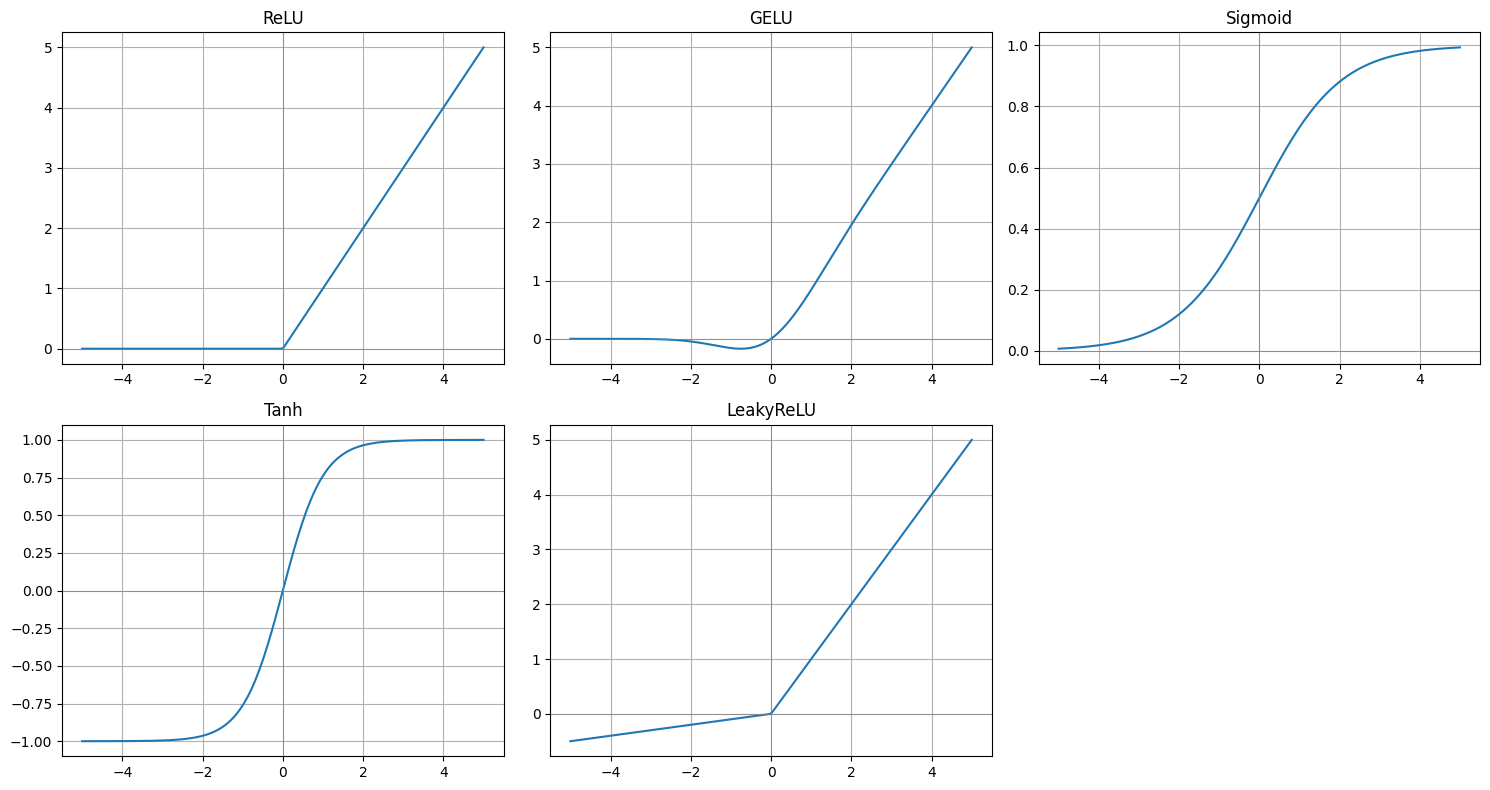

2026-06-01 00:23:31,459 [INFO] linear: Activation functions plotted


In [3]:
log.debug("Visualizing activation functions")

x = torch.linspace(-5, 5, 200)

activations = {
    "ReLU": F.relu(x),
    "GELU": F.gelu(x),
    "Sigmoid": torch.sigmoid(x),
    "Tanh": torch.tanh(x),
    "LeakyReLU": F.leaky_relu(x, 0.1),
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (name, y) in zip(axes.flat, activations.items()):
    ax.plot(x, y)
    ax.set_title(name)
    ax.grid(True)
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)
axes.flat[-1].axis('off')
plt.tight_layout()
plt.show()
log.info("Activation functions plotted")

2026-06-01 00:23:31,464 [DEBUG] linear: Comparing GELU vs ReLU


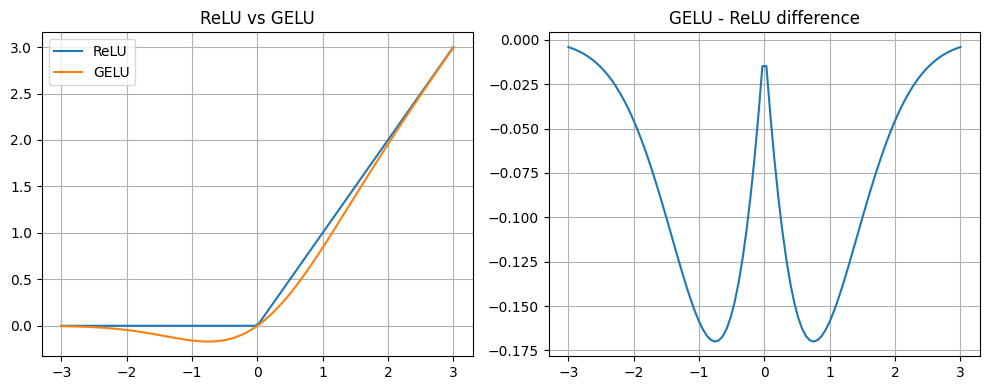

2026-06-01 00:23:31,592 [INFO] linear: GELU vs ReLU comparison shown


In [4]:
log.debug("Comparing GELU vs ReLU")

x = torch.linspace(-3, 3, 100)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(x, F.relu(x), label='ReLU')
plt.plot(x, F.gelu(x), label='GELU')
plt.legend()
plt.grid(True)
plt.title('ReLU vs GELU')

plt.subplot(1, 2, 2)
plt.plot(x, F.gelu(x) - F.relu(x))
plt.title('GELU - ReLU difference')
plt.grid(True)
plt.tight_layout()
plt.show()
log.info("GELU vs ReLU comparison shown")

2026-06-01 00:23:31,596 [DEBUG] linear: Generating synthetic dataset


Dataset: X torch.Size([500, 2]), y torch.Size([500])
Classes: [0, 1]


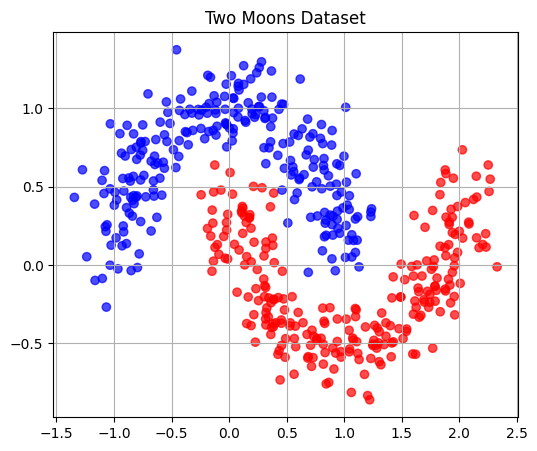

2026-06-01 00:23:31,660 [INFO] linear: Dataset generated: two moons, 500 samples


In [5]:
log.debug("Generating synthetic dataset")

# Two Moons — простой 2D датасет для бинарной классификации
# 500 точек, шум 0.15 (разброс между классами)
X_np, y_np = make_moons(n_samples=500, noise=0.15, random_state=42)
X = torch.tensor(X_np, dtype=torch.float32)
y = torch.tensor(y_np, dtype=torch.long)

print(f"Dataset: X {X.shape}, y {y.shape}")
print(f"Classes: {y.unique().tolist()}")

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', alpha=0.7)
plt.title('Two Moons Dataset')
plt.grid(True)
plt.show()
log.info("Dataset generated: two moons, %d samples", len(X))


In [6]:
# === Определяем модель ===
# nn.Module — базовый класс для всех нейросетей в PyTorch
# В __init__ объявляем слои, в forward описываем их порядок
class SimpleClassifier(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=32, num_classes=2):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)   # 2 → 32
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)  # 32 → 32
        self.fc3 = nn.Linear(hidden_dim, num_classes) # 32 → 2
        
    # forward определяет, как данные проходят через слои
    # После каждого скрытого слоя — нелинейность (ReLU)
    # Последний слой без активации: выход = logits (сырые оценки классов)
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)  # logits для CrossEntropyLoss
        return x

# Создаём модель, функцию потерь и оптимизатор
model = SimpleClassifier().to(device)
criterion = nn.CrossEntropyLoss()  # включает Softmax внутри — не нужно добавлять его в модель
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)  # Adam — адаптивный LR

X, y = X.to(device), y.to(device)
log.info("Model created: %s parameters", sum(p.numel() for p in model.parameters()))


2026-06-01 00:23:32,298 [INFO] linear: Model created: 1218 parameters


In [7]:
log.debug("Training classifier")

losses = []
accs = []
n_epochs = 200

for epoch in range(n_epochs):
    logits = model(X)                          # прямой проход
    loss = criterion(logits, y)                # считаем loss
    
    optimizer.zero_grad()                      # обнуляем градиенты (иначе накопятся)
    loss.backward()                            # обратный проход — считаем градиенты
    
    # Логируем норму градиентов — если падает к нулю, сеть не учится (vanishing gradient)
    if epoch % 50 == 0:
        grad_norm = sum(p.grad.norm().item() for p in model.parameters() if p.grad is not None)
        log.debug("Epoch %d: loss=%.4f, grad_norm=%.4f", epoch, loss.item(), grad_norm)
    
    optimizer.step()                           # шаг оптимизации: W = W - lr * grad
    
    losses.append(loss.item())
    acc = (logits.argmax(1) == y).float().mean().item()  # точность: argmax по классам
    accs.append(acc)

log.info("Training complete: final loss=%.4f, final acc=%.4f", losses[-1], accs[-1])


2026-06-01 00:23:32,302 [DEBUG] linear: Training classifier


2026-06-01 00:23:33,966 [DEBUG] linear: Epoch 0: loss=0.7323, grad_norm=0.7894


2026-06-01 00:23:34,392 [DEBUG] linear: Epoch 50: loss=0.0427, grad_norm=0.0997


2026-06-01 00:23:34,478 [DEBUG] linear: Epoch 100: loss=0.0061, grad_norm=0.0181


2026-06-01 00:23:34,568 [DEBUG] linear: Epoch 150: loss=0.0023, grad_norm=0.0051


2026-06-01 00:23:34,658 [INFO] linear: Training complete: final loss=0.0013, final acc=1.0000


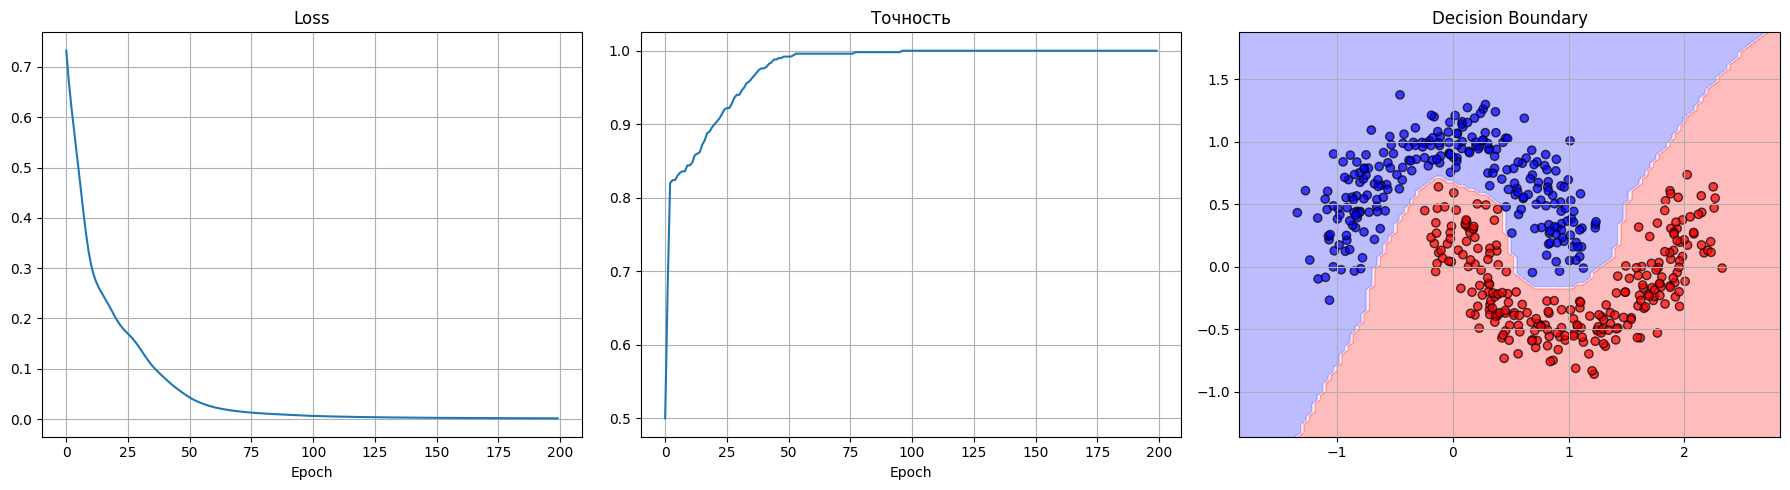

2026-06-01 00:23:35,025 [INFO] linear: Training visualizations complete


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. График loss — должен снижаться
axes[0].plot(losses)
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].grid(True)

# 2. График accuracy — должен расти
axes[1].plot(accs)
axes[1].set_title('Точность')
axes[1].set_xlabel('Epoch')
axes[1].grid(True)

# 3. Граница решения: сетка точек, модель предсказывает класс каждой
# Показывает, как модель разделяет пространство признаков
x_min, x_max = X[:, 0].min().item() - 0.5, X[:, 0].max().item() + 0.5
y_min, y_max = X[:, 1].min().item() - 0.5, X[:, 1].max().item() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32, device=device)
with torch.no_grad():  # отключаем autograd для инференса — экономит память
    Z = model(grid).argmax(1).cpu().numpy().reshape(xx.shape)
axes[2].contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
axes[2].scatter(X[:, 0].cpu(), X[:, 1].cpu(), c=y.cpu(), cmap='bwr', edgecolors='k', alpha=0.7)
axes[2].set_title('Decision Boundary')
axes[2].grid(True)

plt.tight_layout()
plt.show()
log.info("Training visualizations complete")


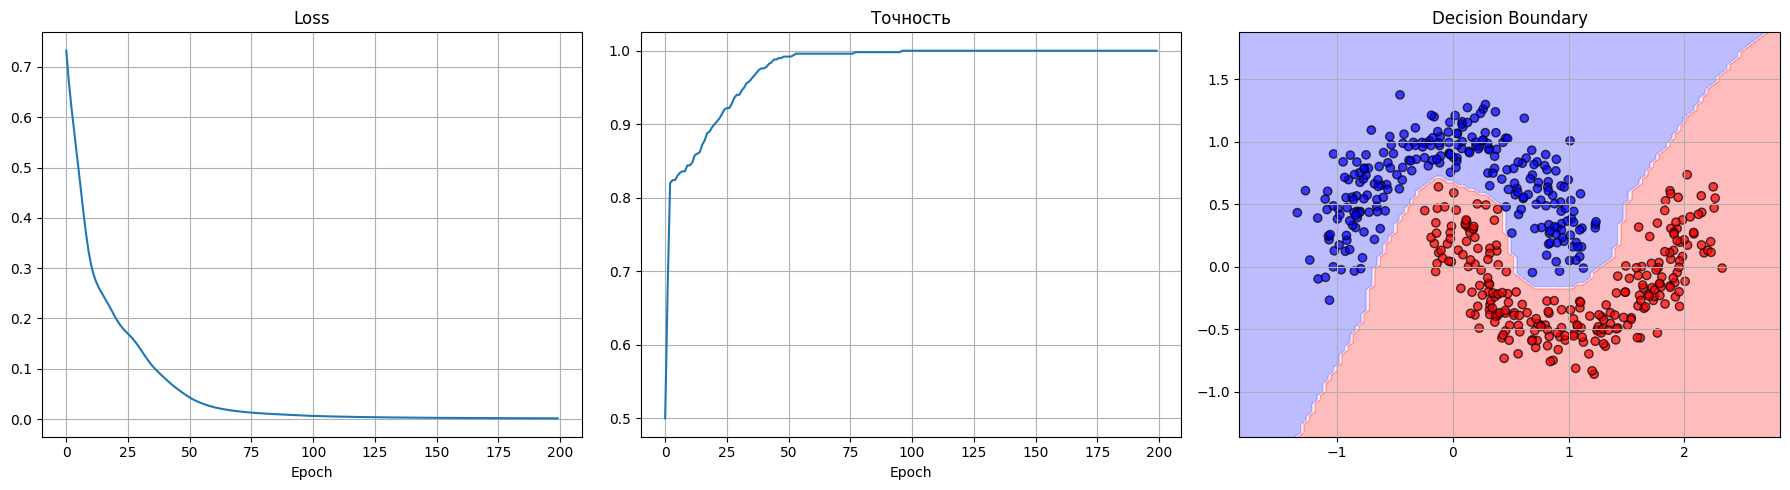

2026-06-01 00:23:35,188 [INFO] linear: Training visualizations complete


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss curve (кривая потерь)
axes[0].plot(losses)
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].grid(True)

# Точность (Accuracy) curve (кривая точности)
axes[1].plot(accs)
axes[1].set_title('Точность')
axes[1].set_xlabel('Epoch')
axes[1].grid(True)

# Decision boundary (граница решения)
x_min, x_max = X[:, 0].min().item() - 0.5, X[:, 0].max().item() + 0.5
y_min, y_max = X[:, 1].min().item() - 0.5, X[:, 1].max().item() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32, device=device)
with torch.no_grad():
    Z = model(grid).argmax(1).cpu().numpy().reshape(xx.shape)
axes[2].contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
axes[2].scatter(X[:, 0].cpu(), X[:, 1].cpu(), c=y.cpu(), cmap='bwr', edgecolors='k', alpha=0.7)
axes[2].set_title('Decision Boundary')
axes[2].grid(True)

plt.tight_layout()
plt.show()
log.info("Training visualizations complete")

# === Сравнение ReLU vs GELU на одинаковой архитектуре ===
# Используем ту же сеть, но заменяем активацию
class ComparativeClassifier(nn.Module):
    def __init__(self, activation=F.relu, hidden_dim=64):
        super().__init__()
        self.activation = activation
        self.fc1 = nn.Linear(2, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, 2)
        
    def forward(self, x):
        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        return self.fc3(x)

# Обучаем две одинаковые сети — разница только в активации
results = {}
for name, act in [("ReLU", F.relu), ("GELU", F.gelu)]:
    m = ComparativeClassifier(activation=act).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=0.01)
    losses = []
    for _ in range(200):
        l = nn.CrossEntropyLoss()(m(X), y)
        opt.zero_grad()
        l.backward()
        opt.step()
        losses.append(l.item())
    results[name] = losses
    log.info("%s classifier final loss: %.4f", name, losses[-1])

# Визуализация: GELU обычно сходится быстрее/стабильнее
plt.figure(figsize=(8, 4))
for name, losses in results.items():
    plt.plot(losses, label=name)
plt.legend()
plt.title('ReLU vs GELU: Convergence')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()


2026-06-01 00:23:35,524 [INFO] linear: ReLU classifier final loss: 0.0004


2026-06-01 00:23:35,879 [INFO] linear: GELU classifier final loss: 0.0015


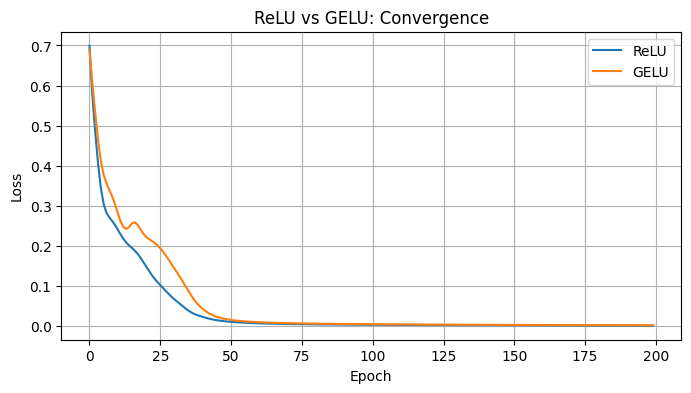

In [10]:
class ComparativeClassifier(nn.Module):
    def __init__(self, activation=F.relu, hidden_dim=64):
        super().__init__()
        self.activation = activation
        self.fc1 = nn.Linear(2, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, 2)
        
    def forward(self, x):
        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        return self.fc3(x)

results = {}
for name, act in [("ReLU", F.relu), ("GELU", F.gelu)]:
    m = ComparativeClassifier(activation=act).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=0.01)
    losses = []
    for _ in range(200):
        l = nn.CrossEntropyLoss()(m(X), y)
        opt.zero_grad()
        l.backward()
        opt.step()
        losses.append(l.item())
    results[name] = losses
    log.info("%s classifier final loss: %.4f", name, losses[-1])

plt.figure(figsize=(8, 4))
for name, losses in results.items():
    plt.plot(losses, label=name)
plt.legend()
plt.title('ReLU vs GELU: Convergence')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

In [11]:
print("=== Linear layers and activations complete ===")
print("Topics covered:")
print("  - nn.Linear internals (weight, bias, manual computation)")
print("  - Activation functions: ReLU, GELU, Sigmoid, Tanh, LeakyReLU")
print("  - GELU vs ReLU: why GELU is preferred in transformers")
print("  - Binary classifier on two moons dataset")
print("  - Training loop, loss curves, accuracy")
print("  - Decision boundary visualization")
print("  - Comparative convergence: ReLU vs GELU")
log.info("Linear layers notebook complete")

2026-06-01 00:23:35,937 [INFO] linear: Linear layers notebook complete


=== Linear layers and activations complete ===
Topics covered:
  - nn.Linear internals (weight, bias, manual computation)
  - Activation functions: ReLU, GELU, Sigmoid, Tanh, LeakyReLU
  - GELU vs ReLU: why GELU is preferred in transformers
  - Binary classifier on two moons dataset
  - Training loop, loss curves, accuracy
  - Decision boundary visualization
  - Comparative convergence: ReLU vs GELU


📚 **Полезные ссылки:**
- [PyTorch: nn.Linear](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html)
- [PyTorch: Weight initialization](https://pytorch.org/docs/stable/nn.init.html)
- [Delving Deep into Rectifiers (Kaiming He, 2015)](https://arxiv.org/abs/1502.01852)
